# 예제 6: 스마트팩토리 AI 종합 대시보드
## 예제 1~5의 모든 기술을 통합한 최종 프로젝트

---

## 이 예제에서 배울 것
- 지금까지 배운 **모든 기술의 통합 활용**
  - 데이터 생성 및 처리 (예제 1)
  - 이상 탐지 AI (예제 3)
  - 시각화 대시보드 (예제 1, 4)
  - 자동 요약 보고 (예제 5 연계)
- **KPI 카드**: 핵심 지표를 한눈에 보여주는 시각화
- **실무 수준 대시보드**: 실제 현장 관리자가 쓸 수 있는 화면 구성

## 핵심 메시지
> **"AI 대시보드는 현장 리더의 판단을 돕는 도구이지, 대체하는 것이 아니다."**  
> 데이터를 한눈에 보고, AI 경보를 받고, 최종 결정은 사람(리더)이 합니다.

## 제조 현장 연관
- 생산·품질·설비·에너지 KPI를 실시간으로 모니터링
- AI 이상 감지 → 즉각 시각적 경보
- 일일/주간 자동 보고서 생성의 기반

In [1]:
# ─────────────────────────────────────────────────────────
# 필요한 도구 설치 및 불러오기
# ─────────────────────────────────────────────────────────
!pip install -q koreanize-matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# GridSpec: 그래프 크기를 세밀하게 조절하는 도구
# (일반 subplots보다 더 유연하게 레이아웃 설정 가능)
import matplotlib.gridspec as gridspec

import koreanize_matplotlib
from sklearn.ensemble import IsolationForest  # 이상 탐지 AI

import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
print("✅ 모든 도구 준비 완료!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 17.7 MB/s eta 0:00:00
✅ 모든 도구 준비 완료!


## STEP 1: 통합 생산 데이터 생성

최근 30일간의 생산·품질·설비·에너지 데이터를 한번에 생성합니다.

In [2]:
# ─────────────────────────────────────────────────────────
# 최근 30일 종합 생산 데이터 생성
# 실제 현장: MES/ERP/SCADA에서 자동으로 수집
# ─────────────────────────────────────────────────────────
np.random.seed(42)

# 최근 30일 날짜 생성
날짜 = pd.date_range('2026-03-20', periods=30, freq='D')  # freq='D': 일별

# ── 생산 데이터 ──────────────────────────────────────────
생산량 = np.random.randint(380, 520, 30)  # 일별 생산량 (380~520개)

# ── 품질 데이터 ──────────────────────────────────────────
# 22~26일에 이상 발생 (불량 급증)
불량수 = np.random.poisson(8, 30)              # 기본 불량수 (포아송 분포)
불량수[22:27] = np.random.poisson(25, 5)       # 22~26일 이상 발생!

# ── 설비 데이터 ──────────────────────────────────────────
가동률 = np.random.uniform(88, 98, 30)         # 설비 가동률 (%)
가동률[22:27] = np.random.uniform(70, 82, 5)   # 이상 시 가동률 하락

# ── 에너지 데이터 ─────────────────────────────────────────
에너지 = np.random.normal(850, 50, 30)         # 일별 에너지 사용량 (kWh)
에너지[22:27] += 120                           # 이상 시 에너지 증가

# ── DataFrame으로 통합 ───────────────────────────────────
df = pd.DataFrame({
    '날짜':        날짜,
    '생산량':      생산량,
    '불량수':      불량수,
    '가동률':      가동률,
    '에너지(kWh)': 에너지
})

# 불량률 계산 (파생 변수)
df['불량률(%)'] = df['불량수'] / df['생산량'] * 100

print(f" 데이터 생성 완료: {len(df)}일치")
print(f"   기간: {날짜[0].date()} ~ {날짜[-1].date()}")
print("\n 데이터 구조:")
df.head(3)

 데이터 생성 완료: 30일치
   기간: 2026-03-20 ~ 2026-04-18

 데이터 구조:


,날짜,생산량,불량수,가동률,에너지(kWh),불량률(%)
0,2026-03-20,482,7,95.440426,850.090681,1.452282
1,2026-03-21,472,5,90.508605,887.796764,1.059322
2,2026-03-22,394,7,89.843337,946.677131,1.776650


## STEP 2: AI 이상 탐지 적용

예제 3에서 배운 Isolation Forest를 대시보드에 통합합니다.

In [3]:
# ─────────────────────────────────────────────────────────
# Isolation Forest로 이상 탐지 (예제 3 복습)
# 불량률, 가동률, 에너지 3가지 지표의 복합 이상을 탐지
# ─────────────────────────────────────────────────────────

# 이상 탐지에 사용할 변수들 선택
X = df[['불량률(%)', '가동률', '에너지(kWh)']]

# IsolationForest 학습 및 예측
iso_model = IsolationForest(
    contamination=0.15,  # 전체의 15%가 이상일 것으로 예상
    random_state=42
)

# fit_predict(): 학습 + 예측 동시 수행
# 1=정상, -1=이상 → True/False로 변환 → int(0/1)로 변환
df['AI_이상'] = (iso_model.fit_predict(X) == -1).astype(bool)

print(f"✅ AI 이상 탐지 완료!")
print(f"   이상으로 판단된 날: {df['AI_이상'].sum()}일")
print(f"   이상 날짜: {list(df[df['AI_이상']]['날짜'].dt.strftime('%m/%d').values)}")

✅ AI 이상 탐지 완료!
   이상으로 판단된 날: 5일
   이상 날짜: ['04/08', '04/11', '04/13', '04/14', '04/15']


## STEP 3: KPI 계산

대시보드에 표시할 핵심 성과 지표(KPI)를 계산합니다.

In [4]:
# ─────────────────────────────────────────────────────────
# 핵심 KPI 계산
# ─────────────────────────────────────────────────────────

# .mean(): 평균값 계산
# .sum(): 합계 계산
이달_불량률   = df['불량률(%)'].mean()      # 이달 평균 불량률
이달_가동률   = df['가동률'].mean()         # 이달 평균 가동률
총_생산량     = df['생산량'].sum()          # 이달 총 생산량
AI_경보건수   = df['AI_이상'].sum()         # AI 이상 감지 건수

# KPI 목표값
목표_불량률 = 2.0   # 2.0% 이하
목표_가동률 = 93.0  # 93% 이상
목표_생산량 = 14.0  # 14,000개 이상 (단위: 천 개)
목표_경보건수 = 3   # 3건 이하

print("=" * 50)
print("📊 이달 KPI 현황")
print("=" * 50)
print(f"  불량률: {이달_불량률:.2f}% "
      f"({'✅ 목표 달성' if 이달_불량률 <= 목표_불량률 else '❌ 목표 초과'})")
print(f"  가동률: {이달_가동률:.1f}% "
      f"({'✅ 목표 달성' if 이달_가동률 >= 목표_가동률 else '❌ 목표 미달'})")
print(f"  생산량: {총_생산량:,}개 ({총_생산량/1000:.1f}천개) "
      f"({'✅ 목표 달성' if 총_생산량/1000 >= 목표_생산량 else '❌ 목표 미달'})")
print(f"  AI 경보: {AI_경보건수}건 "
      f"({'✅ 양호' if AI_경보건수 <= 목표_경보건수 else '❌ 주의'})")

📊 이달 KPI 현황
  불량률: 2.42% (❌ 목표 초과)
  가동률: 89.3% (❌ 목표 미달)
  생산량: 13,523개 (13.5천개) (❌ 목표 미달)
  AI 경보: 5건 (❌ 주의)


## STEP 4: 종합 대시보드 시각화

8개 구성 요소로 이루어진 전문 대시보드를 그립니다.

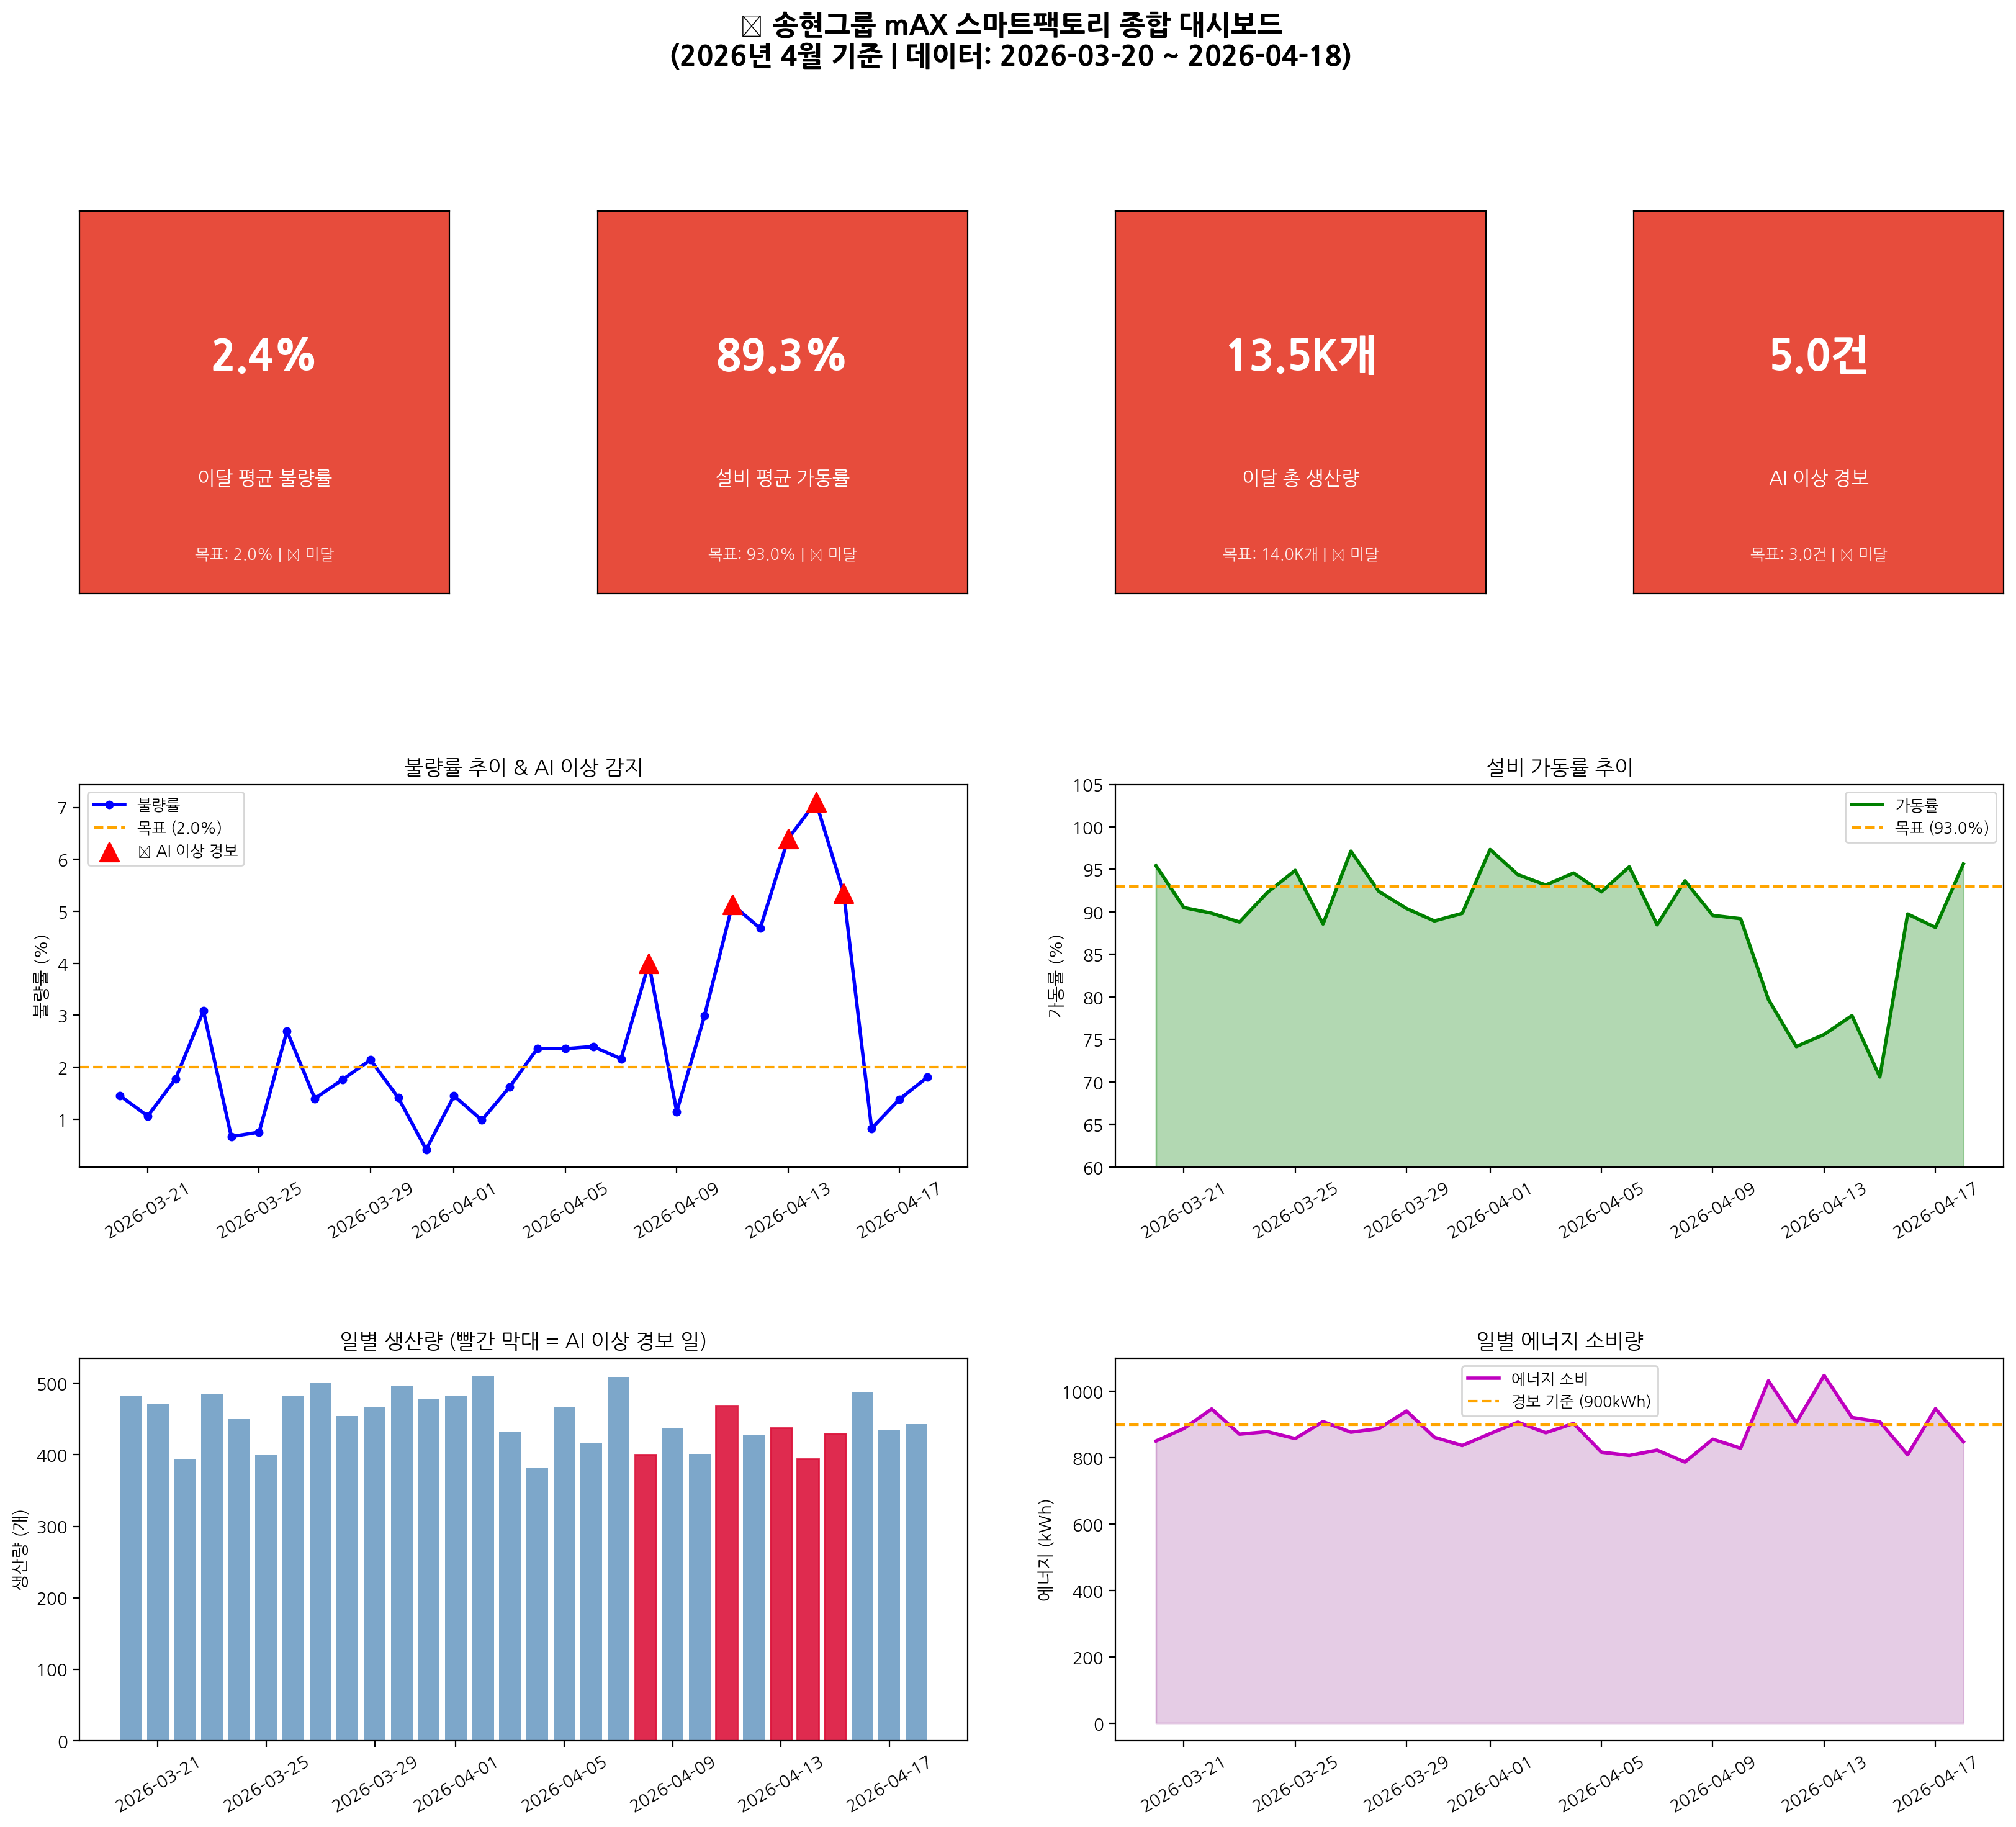

✅ 대시보드 그리기 완료!
   '스마트팩토리_대시보드.png' 파일로 저장됨


In [5]:
# ─────────────────────────────────────────────────────────
# 종합 대시보드 구성
# GridSpec을 사용하여 다양한 크기의 그래프를 배치
# ─────────────────────────────────────────────────────────

# 전체 도화지 설정
# figsize=(가로, 세로): 인치 단위의 전체 크기
fig = plt.figure(figsize=(20, 16))

# 전체 제목
fig.suptitle(
    '📊 송현그룹 mAX 스마트팩토리 종합 대시보드\n'
    f'(2026년 4월 기준 | 데이터: {날짜[0].date()} ~ {날짜[-1].date()})',
    fontsize=16, fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────
# GridSpec 레이아웃 설정
# GridSpec(행수, 열수): 그리드 격자 생성
# hspace: 행 간격 / wspace: 열 간격
# ─────────────────────────────────────────────────────────
gs = gridspec.GridSpec(
    3, 4,            # 3행 4열 구성
    figure=fig,
    hspace=0.5,      # 행 간격
    wspace=0.4       # 열 간격
)

# ─────────────────────────────────────────────────────────
# 【KPI 카드 그리기 함수】
# def: 함수 정의 (코드를 재사용 가능하게 묶기)
# 인자: ax(그래프 축), 제목, 값, 목표, 단위, 방향
# ─────────────────────────────────────────────────────────
def KPI_카드(ax, 제목, 값, 목표, 단위, 방향='낮을수록좋음'):
    """
    KPI 카드를 그리는 함수
    - ax: 그릴 그래프 공간
    - 방향: '낮을수록좋음' 또는 '높을수록좋음'
    """
    # 목표 달성 여부에 따라 색상 결정
    if 방향 == '낮을수록좋음':
        달성 = 값 <= 목표   # 낮을수록 좋으면: 목표 이하일 때 달성
    else:
        달성 = 값 >= 목표   # 높을수록 좋으면: 목표 이상일 때 달성

    배경색 = '#27ae60' if 달성 else '#e74c3c'  # 초록=달성, 빨강=미달

    # 배경색 설정
    ax.set_facecolor(배경색)

    # 숫자 (큰 글씨)
    # transform=ax.transAxes: 0~1 좌표계 (0=왼쪽/아래, 1=오른쪽/위)
    ax.text(0.5, 0.62,  # x=중앙, y=위쪽
            f'{값:.1f}{단위}',
            ha='center', va='center',     # 가운데 정렬
            transform=ax.transAxes,
            fontsize=24, fontweight='bold',
            color='white')

    # 제목
    ax.text(0.5, 0.30, 제목,
            ha='center', va='center',
            transform=ax.transAxes,
            fontsize=11, color='white')

    # 목표값
    달성_표시 = '✅ 달성' if 달성 else '❌ 미달'
    ax.text(0.5, 0.10, f'목표: {목표}{단위} | {달성_표시}',
            ha='center', va='center',
            transform=ax.transAxes,
            fontsize=9, color='white', alpha=0.9)

    # 축 눈금 제거 (깔끔한 카드 외관)
    ax.set_xticks([])
    ax.set_yticks([])

# ─────────────────────────────────────────────────────────
# 【상단】 KPI 카드 4개 (1행)
# fig.add_subplot(gs[행, 열]): 특정 위치에 그래프 추가
# ─────────────────────────────────────────────────────────
ax_kpi1 = fig.add_subplot(gs[0, 0])  # 1행 1열
ax_kpi2 = fig.add_subplot(gs[0, 1])  # 1행 2열
ax_kpi3 = fig.add_subplot(gs[0, 2])  # 1행 3열
ax_kpi4 = fig.add_subplot(gs[0, 3])  # 1행 4열

# 각 KPI 카드 그리기
KPI_카드(ax_kpi1, '이달 평균 불량률', 이달_불량률, 목표_불량률, '%', '낮을수록좋음')
KPI_카드(ax_kpi2, '설비 평균 가동률', 이달_가동률, 목표_가동률, '%', '높을수록좋음')
KPI_카드(ax_kpi3, '이달 총 생산량', 총_생산량/1000, 목표_생산량, 'K개', '높을수록좋음')
KPI_카드(ax_kpi4, 'AI 이상 경보', float(AI_경보건수), float(목표_경보건수), '건', '낮을수록좋음')

# ─────────────────────────────────────────────────────────
# 【중단 왼쪽】 불량률 추이 + AI 경보 표시 (2행 1~2열)
# gs[1, :2]: 2행의 1~2열을 합쳐서 하나의 넓은 그래프로
# ─────────────────────────────────────────────────────────
ax_불량 = fig.add_subplot(gs[1, :2])  # ':2' = 처음부터 2열 전까지

ax_불량.plot(df['날짜'], df['불량률(%)'],
            'b-o', markersize=4, linewidth=2, label='불량률')
ax_불량.axhline(y=목표_불량률, color='orange', linestyle='--',
               linewidth=1.5, label=f'목표 ({목표_불량률}%)')

# AI 이상 감지 날 빨간 삼각형으로 표시
이상일 = df[df['AI_이상']]  # Boolean 필터링: AI_이상이 True인 행만
ax_불량.scatter(이상일['날짜'], 이상일['불량률(%)'],
               color='red', s=120, zorder=5,
               marker='^',  # 삼각형
               label='🔴 AI 이상 경보')

ax_불량.set_title('불량률 추이 & AI 이상 감지', fontsize=12)
ax_불량.set_ylabel('불량률 (%)')
ax_불량.legend(fontsize=9)
ax_불량.tick_params(axis='x', rotation=30)

# ─────────────────────────────────────────────────────────
# 【중단 오른쪽】 가동률 추이 (2행 3~4열)
# ─────────────────────────────────────────────────────────
ax_가동 = fig.add_subplot(gs[1, 2:])  # '2:' = 2열부터 끝까지

# fill_between: 선 아래를 색으로 채우기
ax_가동.fill_between(df['날짜'], df['가동률'],
                    alpha=0.3, color='green')
ax_가동.plot(df['날짜'], df['가동률'],
            'g-', linewidth=2, label='가동률')
ax_가동.axhline(y=목표_가동률, color='orange', linestyle='--',
               linewidth=1.5, label=f'목표 ({목표_가동률}%)')

ax_가동.set_title('설비 가동률 추이', fontsize=12)
ax_가동.set_ylabel('가동률 (%)')
ax_가동.set_ylim([60, 105])  # y축 범위 고정
ax_가동.legend(fontsize=9)
ax_가동.tick_params(axis='x', rotation=30)

# ─────────────────────────────────────────────────────────
# 【하단 왼쪽】 일별 생산량 막대그래프 (3행 1~2열)
# ─────────────────────────────────────────────────────────
ax_생산 = fig.add_subplot(gs[2, :2])

# 막대 그래프 그리기
bars = ax_생산.bar(df['날짜'], df['생산량'],
                  color='steelblue', alpha=0.7)

# AI 이상 감지 날의 막대를 빨간색으로 변경
for i, (date, is_anom) in enumerate(zip(df['날짜'], df['AI_이상'])):
    # zip: 날짜와 이상여부를 쌍으로 묶어서 반복
    if is_anom:  # 이상인 경우
        bars[i].set_color('crimson')  # 빨간색으로 변경
        bars[i].set_alpha(0.9)        # 더 진하게

ax_생산.set_title('일별 생산량 (빨간 막대 = AI 이상 경보 일)', fontsize=12)
ax_생산.set_ylabel('생산량 (개)')
ax_생산.tick_params(axis='x', rotation=30)

# ─────────────────────────────────────────────────────────
# 【하단 오른쪽】 에너지 소비 추이 (3행 3~4열)
# ─────────────────────────────────────────────────────────
ax_에너지 = fig.add_subplot(gs[2, 2:])

ax_에너지.plot(df['날짜'], df['에너지(kWh)'],
             'm-', linewidth=2, label='에너지 소비')
ax_에너지.fill_between(df['날짜'], df['에너지(kWh)'],
                     alpha=0.2, color='purple')
ax_에너지.axhline(y=900, color='orange', linestyle='--',
                label='경보 기준 (900kWh)')

ax_에너지.set_title('일별 에너지 소비량', fontsize=12)
ax_에너지.set_ylabel('에너지 (kWh)')
ax_에너지.legend(fontsize=9)
ax_에너지.tick_params(axis='x', rotation=30)

# ─────────────────────────────────────────────────────────
# 저장 및 출력
# ─────────────────────────────────────────────────────────
plt.savefig('스마트팩토리_대시보드.png',
            dpi=150,              # 해상도 (높을수록 선명, 파일 커짐)
            bbox_inches='tight')  # 여백 자동 조정
plt.show()

print("✅ 대시보드 그리기 완료!")
print("   '스마트팩토리_대시보드.png' 파일로 저장됨")

## STEP 5: 자동 요약 보고서 생성 (텍스트)

In [6]:
# ─────────────────────────────────────────────────────────
# 데이터 기반 자동 요약 보고서 (텍스트 버전)
# 예제 5(LLM)와 연결하면 AI가 이 내용을 자동으로 문장으로 작성
# ─────────────────────────────────────────────────────────

print()
print("=" * 65)
print("📋 이달 생산 현황 자동 요약 보고서")
print("=" * 65)
print(f"작성 기간: {날짜[0].date()} ~ {날짜[-1].date()} (최근 30일)")

print("\n" + "─" * 65)
print("【 핵심 KPI 현황 】")
print("─" * 65)

# 각 KPI를 조건에 따라 다른 메시지 출력
# 삼항 연산자: A if 조건 else B → 조건이 True면 A, False면 B
불량_상태 = "✅ 목표 달성" if 이달_불량률 <= 목표_불량률 else f"❌ 목표({목표_불량률}%) 초과"
가동_상태 = "✅ 목표 달성" if 이달_가동률 >= 목표_가동률 else f"❌ 목표({목표_가동률}%) 미달"

print(f"  □ 이달 평균 불량률: {이달_불량률:.2f}% → {불량_상태}")
print(f"  □ 설비 평균 가동률: {이달_가동률:.1f}% → {가동_상태}")
print(f"  □ 이달 총 생산량:   {총_생산량:,}개")
print(f"  □ AI 이상 경보:     {AI_경보건수}건 발생")

print("\n" + "─" * 65)
print("【 AI 이상 감지 상세 】")
print("─" * 65)

# 이상 발생 날짜와 데이터 출력
if AI_경보건수 > 0:
    이상데이터 = df[df['AI_이상']][['날짜', '불량률(%)', '가동률', '에너지(kWh)']]
    for _, row in 이상데이터.iterrows():
        print(f"  🔴 {row['날짜'].strftime('%m/%d')} — "
              f"불량률 {row['불량률(%)']:.1f}%, "
              f"가동률 {row['가동률']:.0f}%, "
              f"에너지 {row['에너지(kWh)']:.0f}kWh")
else:
    print("  🟢 이달 AI 이상 감지 없음 — 안정적 운영")

print("\n" + "─" * 65)
print("【 AI 권고 사항 】")
print("─" * 65)

# 조건에 따른 자동 권고 생성
if 이달_불량률 > 목표_불량률:
    print(f"  ⚠️  불량률 개선 필요: 이달 {이달_불량률:.2f}% → 목표 {목표_불량률}% 달성 위해")
    # AI 이상일 중 가장 불량률 높은 날 찾기
    최고불량일 = df.loc[df['불량률(%)'].idxmax(), '날짜']
    print(f"         특히 {최고불량일.strftime('%m/%d')} 불량률 집중 분석 권고")
if 이달_가동률 < 목표_가동률:
    print(f"  ⚠️  가동률 개선 필요: 이달 {이달_가동률:.1f}% → 목표 {목표_가동률}% 달성 위해")
    print(f"         비계획 정지 원인 분석 및 예방 보전 강화 필요")
if AI_경보건수 > 목표_경보건수:
    print(f"  ⚠️  AI 경보 {AI_경보건수}건: 목표({목표_경보건수}건) 초과 — 경보 원인 공통 분석 필요")

if 이달_불량률 <= 목표_불량률 and 이달_가동률 >= 목표_가동률 and AI_경보건수 <= 목표_경보건수:
    print("  ✅ 전 지표 목표 달성 — 현재 관리 수준 유지")

print("\n" + "=" * 65)
print("💡 다음 단계: 이 요약 데이터를 Claude API에 전달하면")
print("   전문가 수준의 보고서가 자동으로 생성됩니다! (예제 5 참고)")


📋 이달 생산 현황 자동 요약 보고서
작성 기간: 2026-03-20 ~ 2026-04-18 (최근 30일)

─────────────────────────────────────────────────────────────────
【 핵심 KPI 현황 】
─────────────────────────────────────────────────────────────────
  □ 이달 평균 불량률: 2.42% → ❌ 목표(2.0%) 초과
  □ 설비 평균 가동률: 89.3% → ❌ 목표(93.0%) 미달
  □ 이달 총 생산량:   13,523개
  □ AI 이상 경보:     5건 발생

─────────────────────────────────────────────────────────────────
【 AI 이상 감지 상세 】
─────────────────────────────────────────────────────────────────
  🔴 04/08 — 불량률 4.0%, 가동률 94%, 에너지 787kWh
  🔴 04/11 — 불량률 5.1%, 가동률 80%, 에너지 1032kWh
  🔴 04/13 — 불량률 6.4%, 가동률 76%, 에너지 1048kWh
  🔴 04/14 — 불량률 7.1%, 가동률 78%, 에너지 921kWh
  🔴 04/15 — 불량률 5.3%, 가동률 71%, 에너지 908kWh

─────────────────────────────────────────────────────────────────
【 AI 권고 사항 】
─────────────────────────────────────────────────────────────────
  ⚠️  불량률 개선 필요: 이달 2.42% → 목표 2.0% 달성 위해
         특히 04/14 불량률 집중 분석 권고
  ⚠️  가동률 개선 필요: 이달 89.3% → 목표 93.0% 달성 위해
         비계획 정지 원인 분석 및 예방 보전 강화 필요
  ⚠️  AI 

## 🎓 최종 정리 — 예제 1~6 전체 복습

### 6개 예제에서 배운 것

| 예제 | 기술 | 제조 활용 |
|------|------|----------|
| 1 | 데이터 시각화 (pandas, matplotlib) | 불량 패턴 발견 |
| 2 | 지도학습 — Random Forest | 불량 예측 AI |
| 3 | 비지도학습 — Isolation Forest | 설비 이상 탐지 |
| 4 | 시계열 예측 — Prophet | 수요예측, 생산 계획 |
| 5 | LLM API (Claude) | 보고서 자동 생성 |
| 6 | 통합 대시보드 | 종합 모니터링 |

### 핵심 메시지 3가지

**1. 코드보다 질문이 중요합니다**
```
ChatGPT/Claude에게: "불량률을 라인별로 비교하는 막대그래프 파이썬 코드 써줘"
→ 코드를 즉시 제공합니다. 이걸 복사해서 Colab에 실행하면 됩니다.
```

**2. 작게 시작하여 성과를 확인하세요**
```
전체 공장 X → 1개 라인부터 PoC 시작
완벽한 시스템 X → 엑셀 데이터 하나로 분석 시작
```

**3. AI는 도구, 결정은 사람이**
```
AI: 데이터 분석 + 패턴 발견 + 보고서 초안
리더: 맥락 이해 + 최종 판단 + 실행 지시
```

### 현장 도입 로드맵

```
【1개월】 Colab에서 자사 데이터로 예제 1~2 실행
    ↓
【3개월】 1개 공정에 예제 3(이상탐지) PoC
    ↓
【6개월】 예제 5(LLM 보고서)로 주간 보고 자동화
    ↓
【1년】   예제 6 스타일의 실시간 대시보드 운영
```

---

## 🎉 축하합니다!

**mAX Academy 3기 Python 예제 6선 모두 완주하셨습니다!**

> 오늘 배운 코드는 잊어도 됩니다.  
> **"AI로 이런 것들이 가능하다"**는 경험만으로 충분합니다.  
> 코드는 언제든 ChatGPT/Claude에게 다시 써달라고 하면 됩니다.

---
*송현그룹 mAX Academy 3기 | 예제 6/6 (최종)*  
*2026년 4월*